In [2]:
from langgraph.graph import StateGraph, START, END, MessagesState
from langchain_groq import ChatGroq
from dotenv import load_dotenv

load_dotenv()


c:\Users\Ashutosh Pandey\Desktop\Machine Learning\LangGraph-In-Depth\LangGraph\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


True

In [3]:
llm = ChatGroq(model="openai/gpt-oss-120b", temperature=0.4)

In [4]:
def create_node(state: MessagesState):
    response = llm.invoke(state['messages'])
    return {"messages": [response]}

In [5]:
# building the graph
graph = StateGraph(MessagesState)

graph.add_node("create_node", create_node)
graph.add_edge(START, "create_node")
graph.add_edge("create_node", END)

In [6]:
STM=graph.compile()

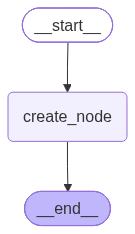

In [7]:
from IPython.display import Image 
Image(STM.get_graph().draw_mermaid_png())

In [8]:
# lets invoke the graph
STM.invoke({"messages": [{"role": "user", "content": "hi my name is ashutosh"}]})

{'messages': [HumanMessage(content='hi my name is ashutosh', additional_kwargs={}, response_metadata={}, id='ade587ef-8b85-4dc5-af1f-8f18f642802c'),
  AIMessage(content='Hello Ashutosh! Nice to meet you. How can I help you today?', additional_kwargs={'reasoning_content': 'The user says "hi my name is ashutosh". Likely a greeting. The assistant should respond politely, maybe ask how can help. No disallowed content. So respond friendly.'}, response_metadata={'token_usage': {'completion_tokens': 65, 'prompt_tokens': 78, 'total_tokens': 143, 'completion_time': 0.138367195, 'completion_tokens_details': {'reasoning_tokens': 39}, 'prompt_time': 0.003808557, 'prompt_tokens_details': None, 'queue_time': 0.34832036, 'total_time': 0.142175752}, 'model_name': 'openai/gpt-oss-120b', 'system_fingerprint': 'fp_fe269835c7', 'service_tier': 'on_demand', 'finish_reason': 'stop', 'logprobs': None, 'model_provider': 'groq'}, id='lc_run--01a0a0bf-b8fb-7c52-82ed-628a0b681f57-0', tool_calls=[], invalid_tool_

In [9]:
STM.invoke({"messages": [{"role": "user", "content": "hi what is my name can you tell me "}]})

{'messages': [HumanMessage(content='hi what is my name can you tell me ', additional_kwargs={}, response_metadata={}, id='9155cc1e-5452-4c22-83fa-423c74fd720a'),
  AIMessage(content='I don’t have any information about your name. If you’d like me to address you by a particular name, just let me know!', additional_kwargs={'reasoning_content': 'The user asks "hi what is my name can you tell me". The assistant does not have any prior context about the user\'s name. According to policy, we must not fabricate personal info. We can respond that we don\'t know the name, ask them to provide it, or say we don\'t have that info. So answer politely.'}, response_metadata={'token_usage': {'completion_tokens': 104, 'prompt_tokens': 81, 'total_tokens': 185, 'completion_time': 0.219107327, 'completion_tokens_details': {'reasoning_tokens': 67}, 'prompt_time': 0.00310195, 'prompt_tokens_details': None, 'queue_time': 0.212535267, 'total_time': 0.222209277}, 'model_name': 'openai/gpt-oss-120b', 'system_fin

In [10]:
# so the above code is the problem if yu dont implement stm memory in them 

In [11]:
# we will create everything same
def chatnode(state: MessagesState):
    response = llm.invoke(state["messages"])
    return {"messages": [response]}

In [12]:
from langgraph.checkpoint.memory import InMemorySaver

In [13]:
graph = StateGraph(MessagesState)


graph.add_node("chatnode", chatnode)
graph.add_edge(START, "chatnode")
graph.add_edge("chatnode", END)

checkpoint = InMemorySaver()

In [14]:
WithSTM = graph.compile(checkpointer=checkpoint)

In [15]:
config = {"configurable": {"thread_id": "1234"}}

In [16]:
WithSTM.invoke({"messages": [{"role": "user", "content": "hi my name is ashutosh"}]}, config)

{'messages': [HumanMessage(content='hi my name is ashutosh', additional_kwargs={}, response_metadata={}, id='9009a847-5dca-4c9b-a3a7-9254dfceab78'),
  AIMessage(content='Hello Ashutosh! 👋 Nice to meet you. How can I assist you today?', additional_kwargs={'reasoning_content': 'We need to respond. The user says "hi my name is ashutosh". We should greet them. Possibly ask how can help. Use friendly tone.'}, response_metadata={'token_usage': {'completion_tokens': 61, 'prompt_tokens': 78, 'total_tokens': 139, 'completion_time': 0.127093099, 'completion_tokens_details': {'reasoning_tokens': 33}, 'prompt_time': 0.032088337, 'prompt_tokens_details': None, 'queue_time': 0.412082779, 'total_time': 0.159181436}, 'model_name': 'openai/gpt-oss-120b', 'system_fingerprint': 'fp_9241e9962b', 'service_tier': 'on_demand', 'finish_reason': 'stop', 'logprobs': None, 'model_provider': 'groq'}, id='lc_run--01a0a0bf-bd90-7530-83f4-e8d2f2b00f98-0', tool_calls=[], invalid_tool_calls=[], usage_metadata={'input_

In [17]:
WithSTM.invoke({"messages": [{"role": "user", "content": "what is my name can you tell me"}]}, config)

{'messages': [HumanMessage(content='hi my name is ashutosh', additional_kwargs={}, response_metadata={}, id='9009a847-5dca-4c9b-a3a7-9254dfceab78'),
  AIMessage(content='Hello Ashutosh! 👋 Nice to meet you. How can I assist you today?', additional_kwargs={'reasoning_content': 'We need to respond. The user says "hi my name is ashutosh". We should greet them. Possibly ask how can help. Use friendly tone.'}, response_metadata={'token_usage': {'completion_tokens': 61, 'prompt_tokens': 78, 'total_tokens': 139, 'completion_time': 0.127093099, 'completion_tokens_details': {'reasoning_tokens': 33}, 'prompt_time': 0.032088337, 'prompt_tokens_details': None, 'queue_time': 0.412082779, 'total_time': 0.159181436}, 'model_name': 'openai/gpt-oss-120b', 'system_fingerprint': 'fp_9241e9962b', 'service_tier': 'on_demand', 'finish_reason': 'stop', 'logprobs': None, 'model_provider': 'groq'}, id='lc_run--01a0a0bf-bd90-7530-83f4-e8d2f2b00f98-0', tool_calls=[], invalid_tool_calls=[], usage_metadata={'input_

In [18]:
snap = WithSTM.get_state(config)
val = snap.values
for m in val.get("messages", []):
    print("-", type(m).__name__,":", m.content)

- HumanMessage : hi my name is ashutosh
- AIMessage : Hello Ashutosh! 👋 Nice to meet you. How can I assist you today?
- HumanMessage : what is my name can you tell me
- AIMessage : Your name is Ashutosh.
